# Minimal Event Model: Current State and Limitation Studies

## Current notebook role

This notebook is the main cumulative analysis script for the reduced 2D event-based Monte Carlo model. It does not restart the project from scratch at each iteration. Instead, it keeps the current minimal architecture and addresses specific limitations one by one, so that the hypothesis can be strengthened, weakened, or falsified under explicit modeling choices.

The current state before the new orientation study is:

- external imposed fields can produce attraction under some shielding assumptions
- the reduced endogenous `body_surface` source model produces robust repulsion over the tested gap range
- replacing side bookkeeping with an explicit reduced force law changed magnitudes more than signs in the tested regime
- replacing finite external support with periodic continuation showed that the external-field result is materially boundary-sensitive

The new addition below addresses another geometric limitation: so far, the two floating bodies were always modeled as parallel rectangles.


## How to read the notebook

The notebook now contains three successive limitation studies built on the same helper module:

1. an explicit reduced force-law alternative to side-impulse bookkeeping
2. a source-support comparison between finite and periodic external forcing
3. a first non-parallel body-orientation comparison using counter-rotated rectangles

Each study is intentionally reduced. None of them should be read as calibrated hydrodynamics. The point is to test whether qualitative attraction or repulsion survives when a previously hidden modeling assumption is exposed and varied.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_ROOT = PROJECT_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from float_sim.event_model import (
    ModelParameters,
    ShieldingModel,
    SourceField,
    event_count_from_source_density,
    plot_ensemble_metric,
    plot_geometry,
    plot_side_metrics,
    run_ensemble,
    run_gap_ensemble_sweep,
    same_force_sign,
    simulate_batch,
    summarize_ensemble,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
np.set_printoptions(precision=3, suppress=True)


## Reduced alternative: explicit boundary-pressure integration

The new alternative keeps the same sampled event field, attenuation law, shielding rule, and self-emission exclusion rule. Only the **force inference** changes.

Two formulations are compared on the same Monte Carlo event realizations:

1. **Bookkeeping inference**: average inward impulse on the inner and outer long sides, then infer gap-closing force from outer minus inner cumulative impulse.
2. **Explicit boundary-pressure rule**: sample the full rectangle perimeter, compute a reduced local pressure contribution from each event onto each boundary sample, multiply by the local inward normal and boundary weight, then sum those force-density contributions to obtain an explicit net force vector.

This is still a toy model in reduced units. It is not a calibrated hydrodynamic law. Its purpose is only to expose the event-to-force mapping more directly and to test whether the qualitative conclusions are robust to that choice.

In [2]:
BASE_SEED = 240
ENSEMBLE_REPEATS = 8
BASE_SOURCE_DENSITY = 8.0
GAPS = np.array([0.1, 0.3, 0.6, 1.0, 1.4, 1.8])
REFERENCE_CASES = [
    ('external / graded / gap 0.3', 0.3, SourceField(), ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)),
    ('external / graded / gap 1.4', 1.4, SourceField(), ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)),
    ('body / graded / gap 0.3', 0.3, SourceField(model='body_surface', emission_offset=0.12), ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)),
    ('body / graded / gap 1.0', 1.0, SourceField(model='body_surface', emission_offset=0.12), ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)),
]

BASE_PARAMS = ModelParameters(
    body_length=3.0,
    body_width=0.4,
    domain_half_length=6.0,
    domain_half_width=4.0,
    attenuation_length=2.5,
    attenuation_power=0.0,
    mean_wave_amplitude=1.0,
    side_samples=17,
    mobility=0.002,
)

GRADED_SHIELDING = ShieldingModel.graded(minimum_transmission=0.15, occlusion_decay_length=0.25)
NO_SHIELDING = ShieldingModel.none()
EXTERNAL_FIELD = SourceField()
BODY_FIELD = SourceField(model='body_surface', emission_offset=0.12)

def events_for(params: ModelParameters, density: float = BASE_SOURCE_DENSITY) -> int:
    return event_count_from_source_density(density, params)

def gap_sweep(source_field: SourceField, shielding_model: ShieldingModel, *, repeats: int = ENSEMBLE_REPEATS):
    return run_gap_ensemble_sweep(
        gaps=GAPS,
        params=BASE_PARAMS,
        n_events=events_for(BASE_PARAMS),
        repeats=repeats,
        seed=BASE_SEED,
        source_field=source_field,
        shielding_model=shielding_model,
    )

def ensemble_at_gap(gap: float, source_field: SourceField, shielding_model: ShieldingModel, *, repeats: int = ENSEMBLE_REPEATS, seed: int = BASE_SEED):
    return run_ensemble(
        gap=gap,
        params=BASE_PARAMS,
        n_events=events_for(BASE_PARAMS),
        repeats=repeats,
        seed=seed,
        source_field=source_field,
        shielding_model=shielding_model,
    )

def summary_rows(summaries):
    rows = []
    for summary in summaries:
        ratio = np.nan if np.isclose(summary.mean_gap_closing_force, 0.0) else summary.explicit_mean_gap_closing_force / summary.mean_gap_closing_force
        rows.append({
            'gap': round(summary.gap, 2),
            'bookkeeping': round(summary.mean_gap_closing_force, 3),
            'explicit': round(summary.explicit_mean_gap_closing_force, 3),
            'explicit_minus_bookkeeping': round(summary.force_law_gap_difference, 3),
            'explicit_to_bookkeeping_ratio': None if np.isnan(ratio) else round(float(ratio), 3),
            'sign_agreement_rate': round(summary.force_law_sign_agreement_rate, 2),
            'bookkeeping_system_net': round(summary.mean_system_net_force_y, 3),
            'explicit_system_net': round(summary.explicit_mean_system_net_force_y, 3),
        })
    return rows

def case_statistics(records):
    bookkeeping = np.array([record.mean_gap_closing_force for record in records], dtype=float)
    explicit = np.array([record.explicit_mean_gap_closing_force for record in records], dtype=float)
    ratio = explicit / bookkeeping
    agreement = [same_force_sign(left, right) for left, right in zip(bookkeeping, explicit, strict=True)]
    return {
        'bookkeeping_mean': float(bookkeeping.mean()),
        'explicit_mean': float(explicit.mean()),
        'ratio_mean': float(np.mean(ratio)),
        'ratio_std': float(np.std(ratio, ddof=0)),
        'corr': float(np.corrcoef(bookkeeping, explicit)[0, 1]),
        'sign_agreement_rate': float(np.mean(agreement)),
        'mean_abs_bookkeeping_system_net_fraction': float(np.mean(np.abs([record.system_net_force_y for record in records])) / np.mean(np.abs(bookkeeping))),
        'mean_abs_explicit_system_net_fraction': float(np.mean(np.abs([record.explicit_system_net_force_y for record in records])) / np.mean(np.abs(explicit))),
    }

def plot_sign_agreement(ax, summaries, *, label: str, color: str):
    gaps = np.array([summary.gap for summary in summaries], dtype=float)
    rates = np.array([summary.force_law_sign_agreement_rate for summary in summaries], dtype=float)
    ax.plot(gaps, rates, marker='o', color=color, label=label)
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel('Edge-to-edge gap')
    ax.set_ylabel('Agreement rate across seeds')
    ax.set_title('Force-law sign agreement')
    ax.legend(loc='best')

def plot_force_scatter(ax, cases):
    palette = ['#1d3557', '#457b9d', '#e76f51', '#2a9d8f']
    all_values = []
    for color, (label, records) in zip(palette, cases.items(), strict=True):
        bookkeeping = np.array([record.mean_gap_closing_force for record in records], dtype=float)
        explicit = np.array([record.explicit_mean_gap_closing_force for record in records], dtype=float)
        all_values.extend(bookkeeping.tolist())
        all_values.extend(explicit.tolist())
        ax.scatter(bookkeeping, explicit, color=color, alpha=0.8, s=28, label=label)
    limit = max(abs(value) for value in all_values)
    ax.plot([-limit, limit], [-limit, limit], linestyle='--', color='0.5', linewidth=1.0)
    ax.set_xlabel('Bookkeeping gap-closing force')
    ax.set_ylabel('Explicit gap-closing force')
    ax.set_title('Per-run force comparison')
    ax.legend(loc='best', fontsize=8)

def plot_ratio_boxplot(ax, cases):
    labels = list(cases)
    values = []
    for label in labels:
        records = cases[label]
        bookkeeping = np.array([record.mean_gap_closing_force for record in records], dtype=float)
        explicit = np.array([record.explicit_mean_gap_closing_force for record in records], dtype=float)
        values.append(explicit / bookkeeping)
    ax.boxplot(values, tick_labels=labels, showmeans=True)
    ax.axhline(1.0, color='0.4', linestyle='--', linewidth=1.0)
    ax.set_ylabel('Explicit / bookkeeping')
    ax.set_title('Per-run force ratio')
    ax.tick_params(axis='x', rotation=15)


## Ensemble methodology

The event field, attenuation law, shielding rule, gap grid, source density, and deterministic seed schedule are held fixed. Each point below is an ensemble over multiple seeds, so the two force formulations are compared on the same reduced model rather than on separately tuned setups.

Two source processes remain in view because the previous iteration showed they matter strongly:

- `uniform` external source field
- `body_surface` endogenous source field with a small outward emission offset

The main robustness question is therefore: does the qualitative attraction/repulsion story survive the force-law change once the source-process choice is held fixed?

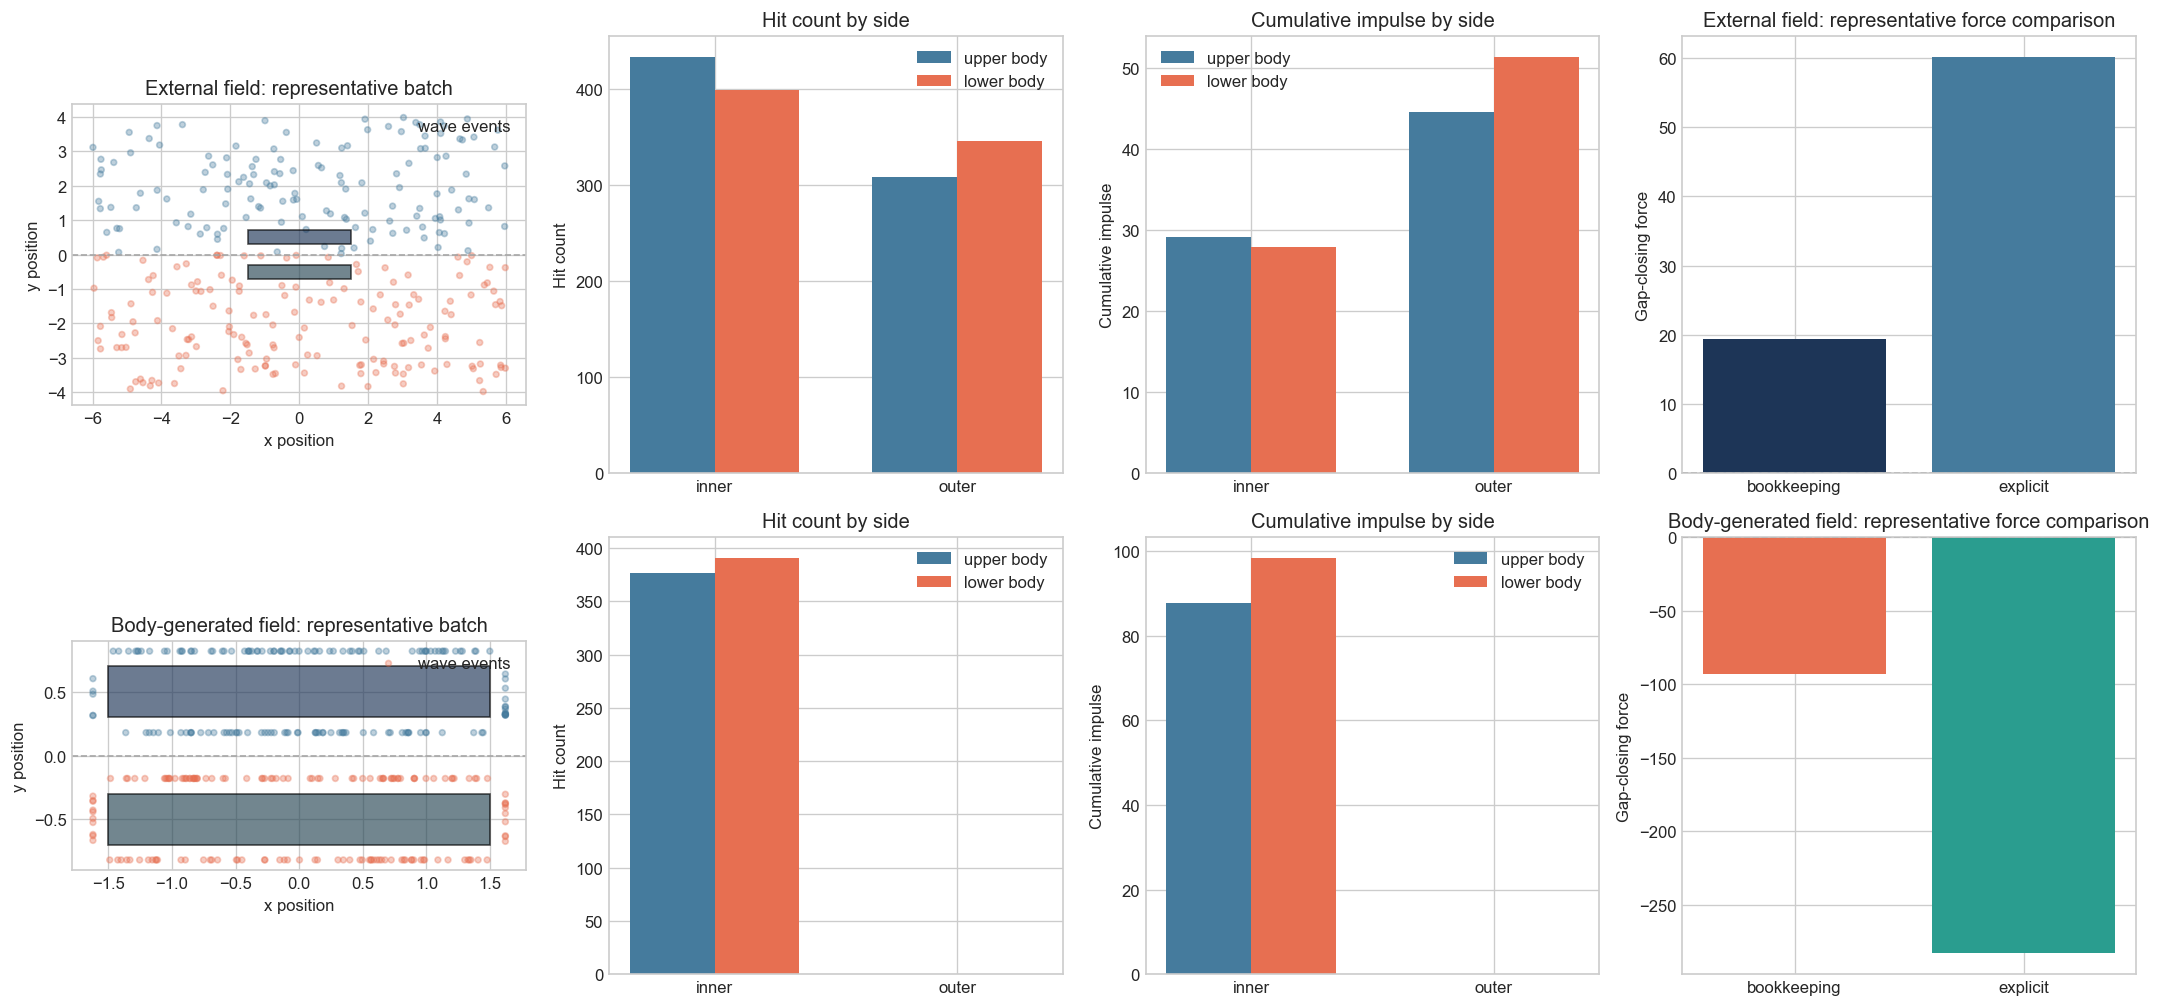

{'external_bookkeeping': 19.349, 'external_explicit': 60.174, 'body_bookkeeping': -93.107, 'body_explicit': -282.944}


In [3]:
external_batch = simulate_batch(
    gap=0.6,
    params=BASE_PARAMS,
    rng=np.random.default_rng(BASE_SEED),
    n_events=events_for(BASE_PARAMS),
    source_field=EXTERNAL_FIELD,
    shielding_model=GRADED_SHIELDING,
)
body_batch = simulate_batch(
    gap=0.6,
    params=BASE_PARAMS,
    rng=np.random.default_rng(BASE_SEED),
    n_events=events_for(BASE_PARAMS),
    source_field=BODY_FIELD,
    shielding_model=GRADED_SHIELDING,
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
plot_geometry(axes[0, 0], external_batch, max_events=300)
plot_side_metrics(axes[0, 1], external_batch, metric='hits')
plot_side_metrics(axes[0, 2], external_batch, metric='impulse')
axes[0, 3].bar(['bookkeeping', 'explicit'], [external_batch.mean_gap_closing_force, external_batch.explicit_mean_gap_closing_force], color=['#1d3557', '#457b9d'])
axes[0, 3].axhline(0.0, color='0.4', linestyle='--', linewidth=1.0)
axes[0, 3].set_title('External field: representative force comparison')
axes[0, 3].set_ylabel('Gap-closing force')

plot_geometry(axes[1, 0], body_batch, max_events=300)
plot_side_metrics(axes[1, 1], body_batch, metric='hits')
plot_side_metrics(axes[1, 2], body_batch, metric='impulse')
axes[1, 3].bar(['bookkeeping', 'explicit'], [body_batch.mean_gap_closing_force, body_batch.explicit_mean_gap_closing_force], color=['#e76f51', '#2a9d8f'])
axes[1, 3].axhline(0.0, color='0.4', linestyle='--', linewidth=1.0)
axes[1, 3].set_title('Body-generated field: representative force comparison')
axes[1, 3].set_ylabel('Gap-closing force')

axes[0, 0].set_title('External field: representative batch')
axes[1, 0].set_title('Body-generated field: representative batch')
fig.tight_layout()
plt.show()

print({
    'external_bookkeeping': round(external_batch.mean_gap_closing_force, 3),
    'external_explicit': round(external_batch.explicit_mean_gap_closing_force, 3),
    'body_bookkeeping': round(body_batch.mean_gap_closing_force, 3),
    'body_explicit': round(body_batch.explicit_mean_gap_closing_force, 3),
})


## Results comparing old vs new force inference

The next comparison keeps the source process fixed and asks whether the sign of the interaction changes when the force law changes. The explicit formulation is allowed to differ in magnitude because it integrates a reduced pressure density over the full boundary rather than inferring force only from long-side bookkeeping.

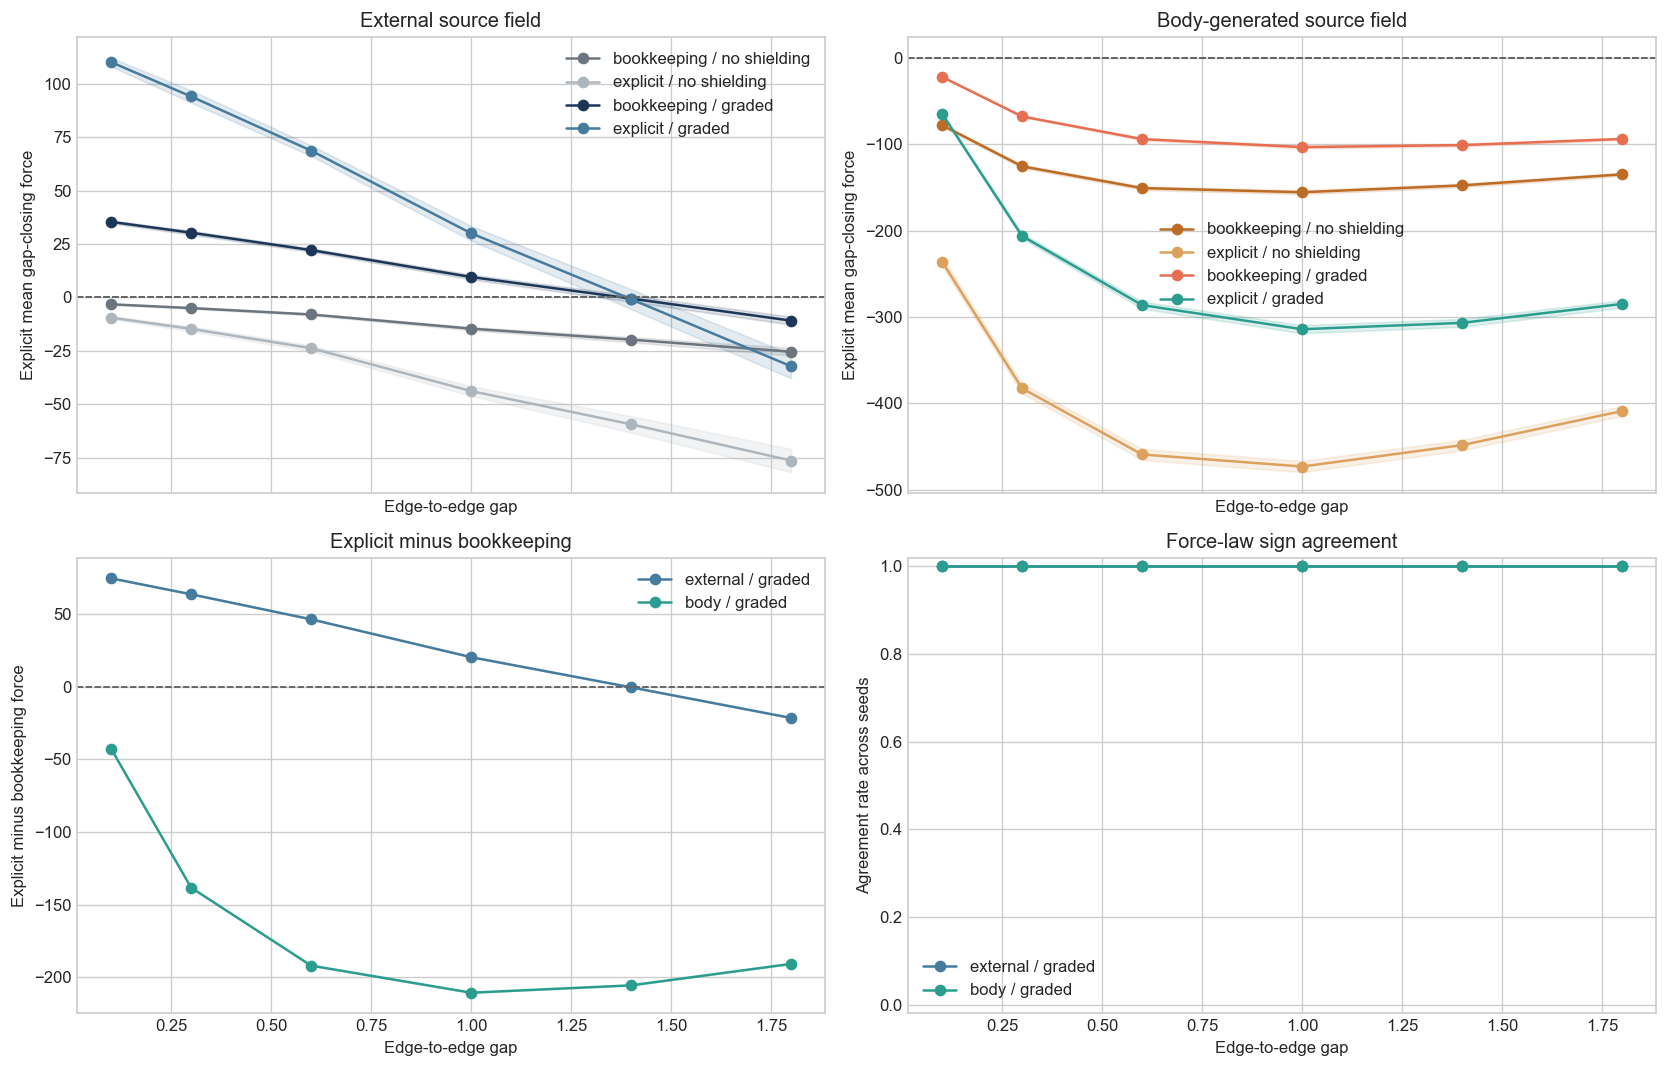

external / graded
{'gap': 0.1, 'bookkeeping': 35.41, 'explicit': 110.248, 'explicit_minus_bookkeeping': 74.837, 'explicit_to_bookkeeping_ratio': 3.113, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net': -3.509, 'explicit_system_net': -9.927}
{'gap': 0.3, 'bookkeeping': 30.333, 'explicit': 94.173, 'explicit_minus_bookkeeping': 63.841, 'explicit_to_bookkeeping_ratio': 3.105, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net': -1.575, 'explicit_system_net': -4.937}
{'gap': 0.6, 'bookkeeping': 22.19, 'explicit': 68.782, 'explicit_minus_bookkeeping': 46.592, 'explicit_to_bookkeeping_ratio': 3.1, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net': -2.958, 'explicit_system_net': -8.889}
{'gap': 1.0, 'bookkeeping': 9.575, 'explicit': 30.085, 'explicit_minus_bookkeeping': 20.51, 'explicit_to_bookkeeping_ratio': 3.142, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net': 2.44, 'explicit_system_net': 7.176}
{'gap': 1.4, 'bookkeeping': -0.523, 'explicit': -0.798, 'explicit_minus_bookkeepin

In [4]:
external_no_shield = gap_sweep(EXTERNAL_FIELD, NO_SHIELDING)
external_graded = gap_sweep(EXTERNAL_FIELD, GRADED_SHIELDING)
body_no_shield = gap_sweep(BODY_FIELD, NO_SHIELDING)
body_graded = gap_sweep(BODY_FIELD, GRADED_SHIELDING)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

plot_ensemble_metric(axes[0, 0], external_no_shield, metric='gap_closing_force', label='bookkeeping / no shielding', color='#6c757d')
plot_ensemble_metric(axes[0, 0], external_no_shield, metric='explicit_gap_closing_force', label='explicit / no shielding', color='#adb5bd')
plot_ensemble_metric(axes[0, 0], external_graded, metric='gap_closing_force', label='bookkeeping / graded', color='#1d3557')
plot_ensemble_metric(axes[0, 0], external_graded, metric='explicit_gap_closing_force', label='explicit / graded', color='#457b9d')
axes[0, 0].set_title('External source field')

plot_ensemble_metric(axes[0, 1], body_no_shield, metric='gap_closing_force', label='bookkeeping / no shielding', color='#bc6c25')
plot_ensemble_metric(axes[0, 1], body_no_shield, metric='explicit_gap_closing_force', label='explicit / no shielding', color='#dda15e')
plot_ensemble_metric(axes[0, 1], body_graded, metric='gap_closing_force', label='bookkeeping / graded', color='#e76f51')
plot_ensemble_metric(axes[0, 1], body_graded, metric='explicit_gap_closing_force', label='explicit / graded', color='#2a9d8f')
axes[0, 1].set_title('Body-generated source field')

plot_ensemble_metric(axes[1, 0], external_graded, metric='force_law_gap_difference', label='external / graded', color='#457b9d')
plot_ensemble_metric(axes[1, 0], body_graded, metric='force_law_gap_difference', label='body / graded', color='#2a9d8f')
axes[1, 0].set_title('Explicit minus bookkeeping')

plot_sign_agreement(axes[1, 1], external_graded, label='external / graded', color='#457b9d')
plot_sign_agreement(axes[1, 1], body_graded, label='body / graded', color='#2a9d8f')

fig.tight_layout()
plt.show()

print('external / graded')
for row in summary_rows(external_graded):
    print(row)
print()
print('body / graded')
for row in summary_rows(body_graded):
    print(row)


## Diagnostics and controls

Mean curves alone are not enough. The diagnostics below check whether the force-law comparison is being driven by sign flips, unstable seed-by-seed behavior, or loss of the expected symmetry control.

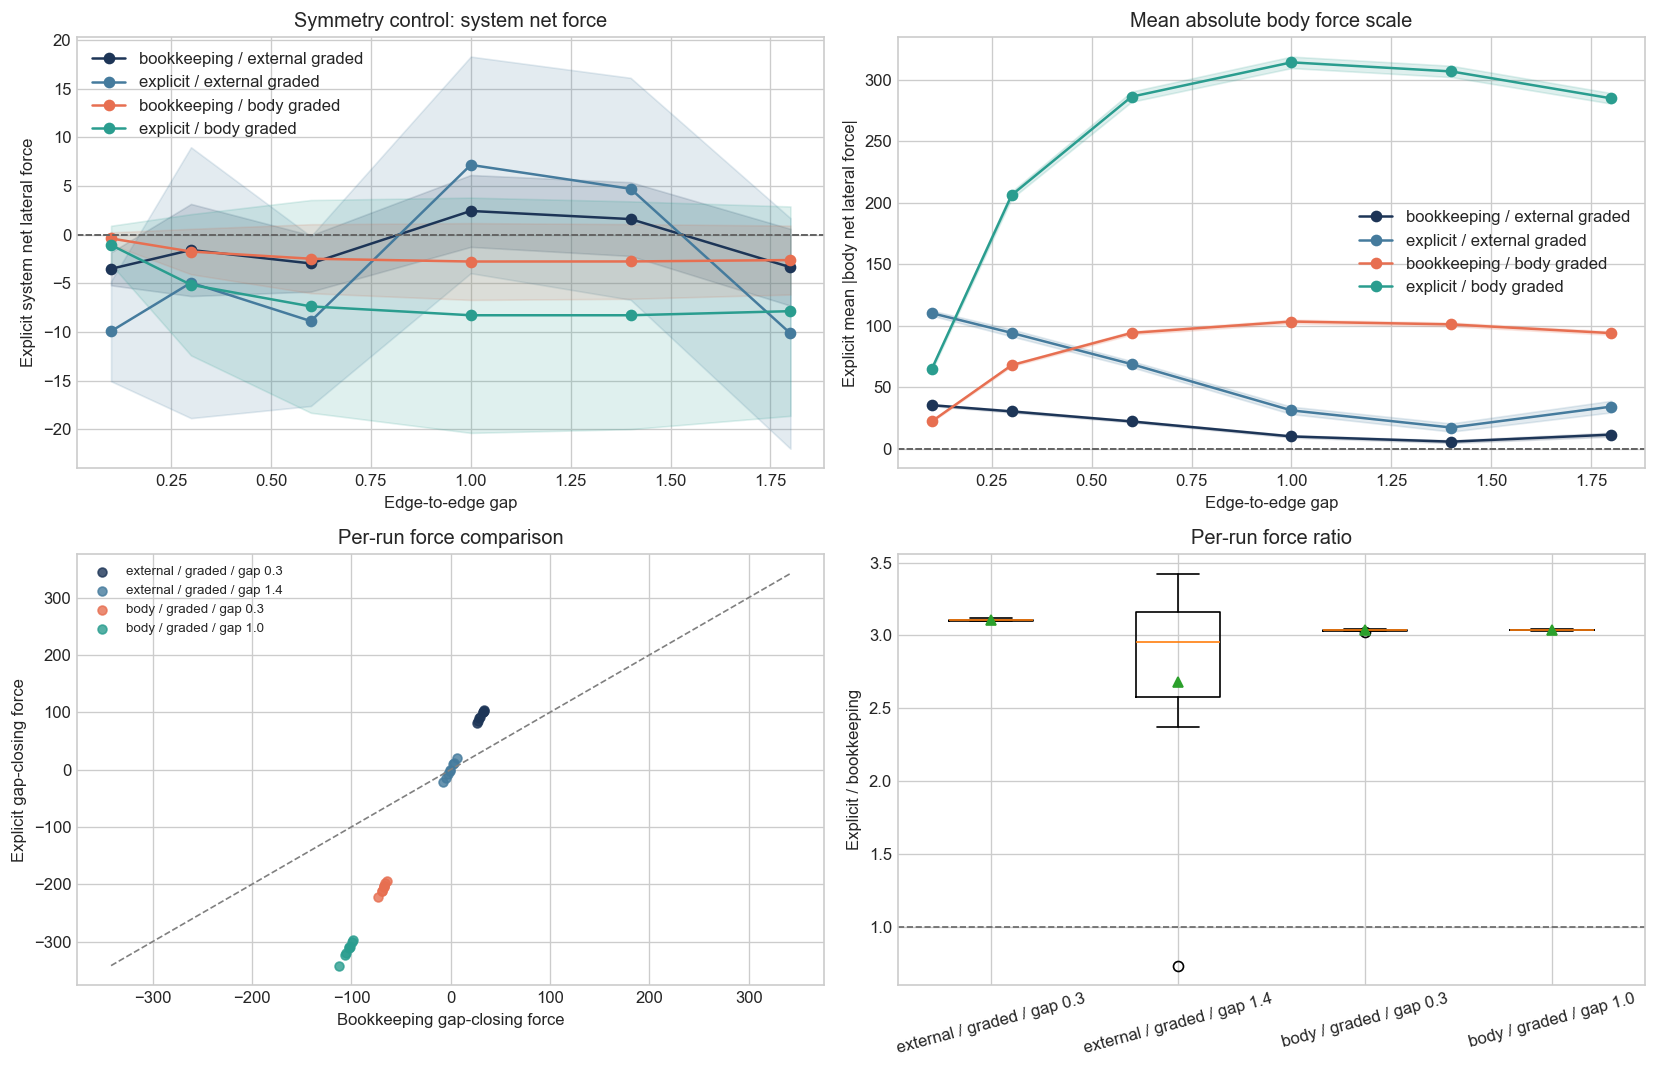

external / graded / gap 0.3
{'bookkeeping_mean': 30.333, 'explicit_mean': 94.173, 'ratio_mean': 3.105, 'ratio_std': 0.007, 'corr': 1.0, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net_fraction': 0.325, 'explicit_system_net_fraction': 0.308}

external / graded / gap 1.4
{'bookkeeping_mean': -0.523, 'explicit_mean': -0.798, 'ratio_mean': 2.68, 'ratio_std': 0.799, 'corr': 1.0, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net_fraction': 2.218, 'explicit_system_net_fraction': 2.234}

body / graded / gap 0.3
{'bookkeeping_mean': -67.952, 'explicit_mean': -206.258, 'ratio_mean': 3.035, 'ratio_std': 0.007, 'corr': 0.998, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net_fraction': 0.09, 'explicit_system_net_fraction': 0.093}

body / graded / gap 1.0
{'bookkeeping_mean': -103.408, 'explicit_mean': -314.149, 'ratio_mean': 3.038, 'ratio_std': 0.003, 'corr': 1.0, 'sign_agreement_rate': 1.0, 'bookkeeping_system_net_fraction': 0.1, 'explicit_system_net_fraction': 0.101}



In [5]:
diagnostic_cases = {
    label: ensemble_at_gap(gap, field, shielding)
    for label, gap, field, shielding in REFERENCE_CASES
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_ensemble_metric(axes[0, 0], external_graded, metric='system_net_force', label='bookkeeping / external graded', color='#1d3557')
plot_ensemble_metric(axes[0, 0], external_graded, metric='explicit_system_net_force', label='explicit / external graded', color='#457b9d')
plot_ensemble_metric(axes[0, 0], body_graded, metric='system_net_force', label='bookkeeping / body graded', color='#e76f51')
plot_ensemble_metric(axes[0, 0], body_graded, metric='explicit_system_net_force', label='explicit / body graded', color='#2a9d8f')
axes[0, 0].set_title('Symmetry control: system net force')

plot_ensemble_metric(axes[0, 1], external_graded, metric='mean_abs_net_force', label='bookkeeping / external graded', color='#1d3557')
plot_ensemble_metric(axes[0, 1], external_graded, metric='explicit_mean_abs_net_force', label='explicit / external graded', color='#457b9d')
plot_ensemble_metric(axes[0, 1], body_graded, metric='mean_abs_net_force', label='bookkeeping / body graded', color='#e76f51')
plot_ensemble_metric(axes[0, 1], body_graded, metric='explicit_mean_abs_net_force', label='explicit / body graded', color='#2a9d8f')
axes[0, 1].set_title('Mean absolute body force scale')

plot_force_scatter(axes[1, 0], diagnostic_cases)
plot_ratio_boxplot(axes[1, 1], diagnostic_cases)

fig.tight_layout()
plt.show()

for label, records in diagnostic_cases.items():
    stats = case_statistics(records)
    print(label)
    print({
        'bookkeeping_mean': round(stats['bookkeeping_mean'], 3),
        'explicit_mean': round(stats['explicit_mean'], 3),
        'ratio_mean': round(stats['ratio_mean'], 3),
        'ratio_std': round(stats['ratio_std'], 3),
        'corr': round(stats['corr'], 3),
        'sign_agreement_rate': round(stats['sign_agreement_rate'], 2),
        'bookkeeping_system_net_fraction': round(stats['mean_abs_bookkeeping_system_net_fraction'], 3),
        'explicit_system_net_fraction': round(stats['mean_abs_explicit_system_net_fraction'], 3),
    })
    print()


## Interpretation

Across the tested sweeps and seeds, the qualitative interaction is **robust to this force-law change in sign, but not in magnitude**. In the present reduced model:

- the explicit boundary-pressure rule and the original bookkeeping rule agree on attraction vs repulsion across the tested gaps
- the explicit rule typically produces larger force magnitudes, often by about a factor of three away from the external-field zero crossing
- the body-generated source field still yields robust repulsion across the tested gap range under both formulations
- the externally imposed field with graded shielding still yields attraction at smaller gaps and weakens or changes sign at larger gaps under both formulations

So the main conclusion from the previous iteration survives this one: the **source-process assumption still matters more than this particular force-law choice** in the current reduced model.

Where the two formulations differ most interpretively is near the external-field zero crossing. Around that regime, both forces are small enough that ratios become unstable and system-net-force diagnostics look worse simply because the interaction denominator is close to zero. That is a fragility of the near-null regime, not evidence that one formulation restores attraction or repulsion by itself.

## Limitations

This notebook still does **not** provide a calibrated hydrodynamic force law. The explicit alternative is only a more direct reduced mapping from event field to net force. Important simplifications remain:

- the event field is still point-based rather than a resolved wave field
- the pressure contribution is defined by a reduced directional attenuation rule, not by fluid mechanics
- boundary sampling density and rectangle geometry still matter
- rotation, tangential response, reflection, and interference remain excluded

The correct reading is therefore limited: under this family of reduced assumptions, the sign of the interaction appears robust to the force-law replacement tested here, while the magnitude is formulation-dependent.

## Recommended next step

The next sensible step is **not** to add high-complexity fluid simulation. It is to keep both reduced force formulations and test whether the same qualitative source-process split survives a slightly richer event-field model, such as directional outward emission, angular emission kernels, or a short-range reflected component. That would probe whether the current sign robustness is specific to the force law, or whether it persists when the endogenous source model itself becomes less isotropic.

## Limitation 4: Finite rectangular source support

The external source fields are currently sampled from a finite rectangle. That is a modeling choice, not a neutral background assumption: truncating the support changes which distant events exist, and therefore changes the net force.

A reduced way to address this, without pretending to solve full wave physics, is to separate the **source process** from the **source support**. Below, the original finite rectangle is kept as the control and compared to a periodic rectangular continuation of the same sampled tile. The periodic continuation is still reduced, but it removes the special status of the outer rectangle boundary.


In [6]:
SUPPORT_BASE_SEED = 410
SUPPORT_REPEATS = 3
SUPPORT_SOURCE_DENSITY = 1.0
SUPPORT_GAPS = np.array([0.3, 0.6, 1.0, 1.4])
SUPPORT_REFERENCE_GAP = 0.6

SUPPORT_SMALL_PARAMS = ModelParameters(
    body_length=3.0,
    body_width=0.4,
    domain_half_length=4.0,
    domain_half_width=3.0,
    attenuation_length=2.5,
    attenuation_power=0.0,
    mean_wave_amplitude=1.0,
    side_samples=17,
    mobility=0.002,
)
SUPPORT_LARGE_PARAMS = ModelParameters(
    body_length=3.0,
    body_width=0.4,
    domain_half_length=8.0,
    domain_half_width=6.0,
    attenuation_length=2.5,
    attenuation_power=0.0,
    mean_wave_amplitude=1.0,
    side_samples=17,
    mobility=0.002,
)

FINITE_SUPPORT_FIELD = SourceField()
PERIODIC_SUPPORT_FIELD = SourceField(support='periodic_rectangle', periodic_image_layers=1)
PERIODIC_SUPPORT_FIELD_L2 = SourceField(support='periodic_rectangle', periodic_image_layers=2)
PERIODIC_SUPPORT_FIELD_L3 = SourceField(support='periodic_rectangle', periodic_image_layers=3)

def support_events_for(params: ModelParameters) -> int:
    return event_count_from_source_density(SUPPORT_SOURCE_DENSITY, params)

def support_gap_sweep(params: ModelParameters, source_field: SourceField):
    return run_gap_ensemble_sweep(
        gaps=SUPPORT_GAPS,
        params=params,
        n_events=support_events_for(params),
        repeats=SUPPORT_REPEATS,
        seed=SUPPORT_BASE_SEED,
        source_field=source_field,
        shielding_model=GRADED_SHIELDING,
    )

def support_summary_at_gap(params: ModelParameters, source_field: SourceField, gap: float = SUPPORT_REFERENCE_GAP):
    return summarize_ensemble(
        run_ensemble(
            gap=gap,
            params=params,
            n_events=support_events_for(params),
            repeats=SUPPORT_REPEATS,
            seed=SUPPORT_BASE_SEED,
            source_field=source_field,
            shielding_model=GRADED_SHIELDING,
        )
    )

def support_delta_rows(gap: float = SUPPORT_REFERENCE_GAP):
    rows = []
    for label, source_field in [
        ('finite rectangle', FINITE_SUPPORT_FIELD),
        ('periodic rectangle, 1 image ring', PERIODIC_SUPPORT_FIELD),
    ]:
        small = support_summary_at_gap(SUPPORT_SMALL_PARAMS, source_field, gap=gap)
        large = support_summary_at_gap(SUPPORT_LARGE_PARAMS, source_field, gap=gap)
        rows.append({
            'support': label,
            'gap': gap,
            'small_bookkeeping': round(small.mean_gap_closing_force, 3),
            'large_bookkeeping': round(large.mean_gap_closing_force, 3),
            'abs_delta_bookkeeping': round(abs(small.mean_gap_closing_force - large.mean_gap_closing_force), 3),
            'small_explicit': round(small.explicit_mean_gap_closing_force, 3),
            'large_explicit': round(large.explicit_mean_gap_closing_force, 3),
            'abs_delta_explicit': round(abs(small.explicit_mean_gap_closing_force - large.explicit_mean_gap_closing_force), 3),
        })
    return rows


## Results: finite rectangle versus periodic continuation

The comparison below keeps the same external uniform source process and the same graded shielding rule. Only the support of the source field changes. If the finite rectangular truncation is driving the result, the small-domain and large-domain curves should differ strongly under the finite control and move closer together under periodic continuation.


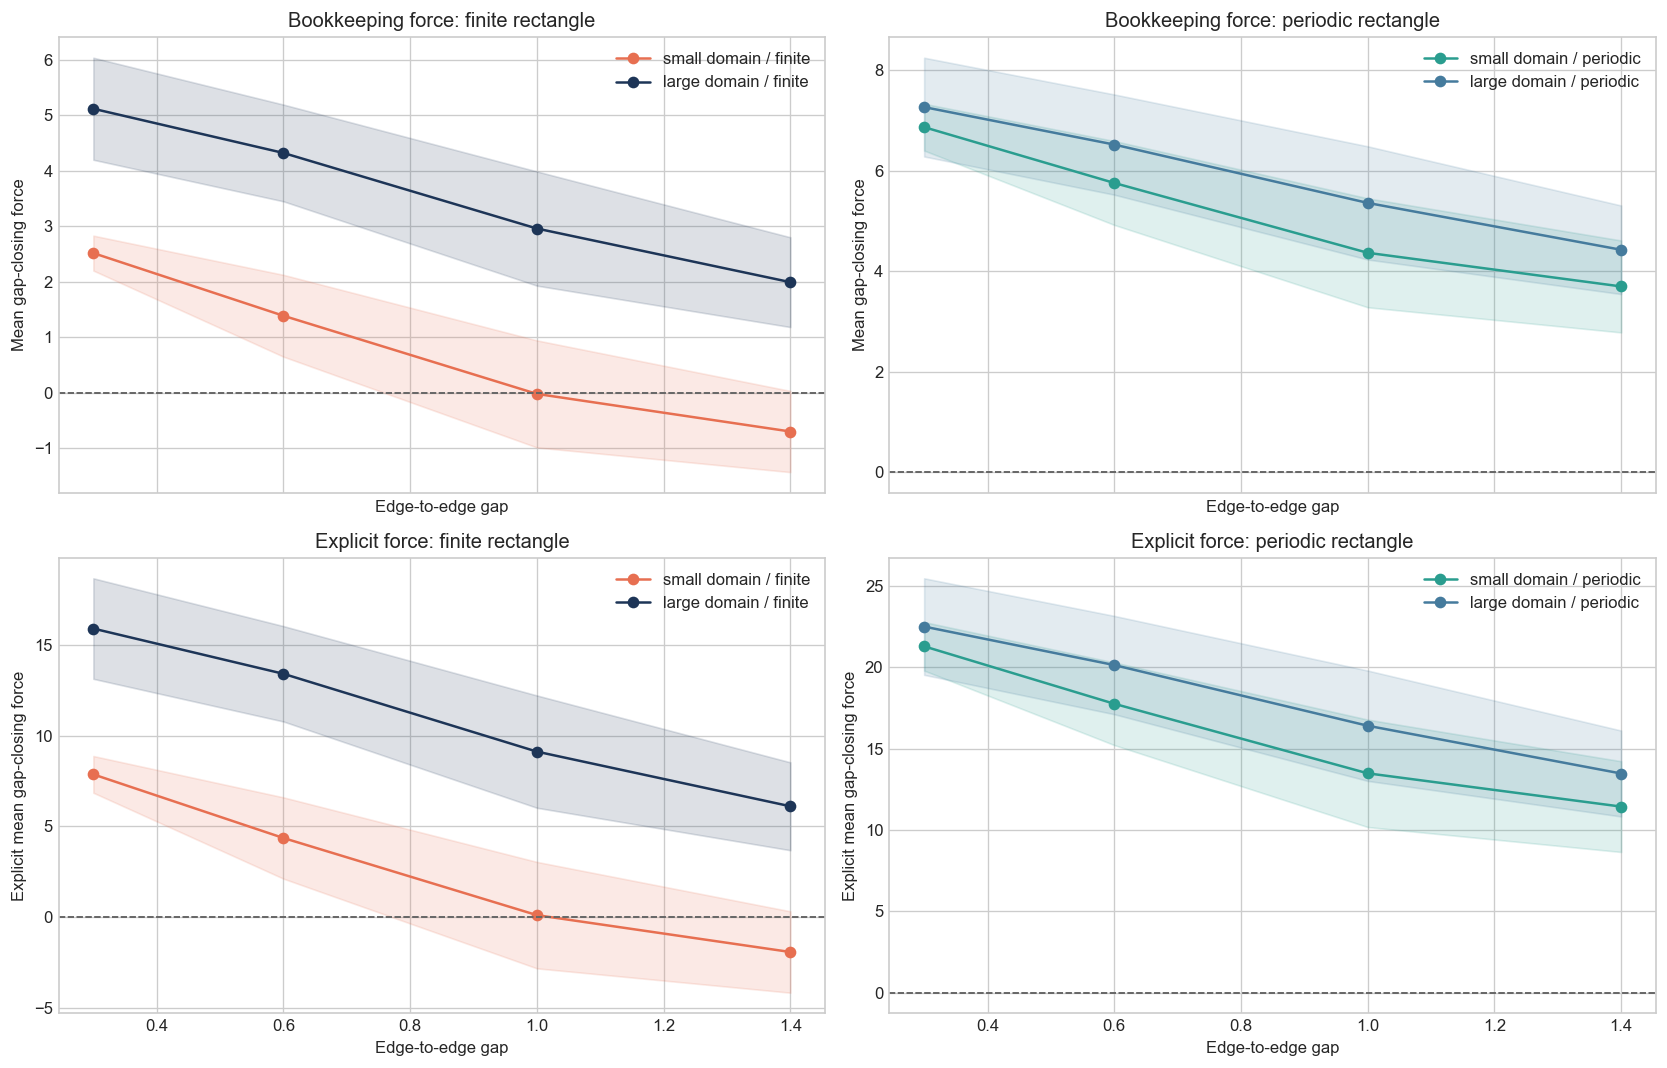

{'support': 'finite rectangle', 'gap': 0.6, 'small_bookkeeping': 1.39, 'large_bookkeeping': 4.323, 'abs_delta_bookkeeping': 2.934, 'small_explicit': 4.361, 'large_explicit': 13.407, 'abs_delta_explicit': 9.046}
{'support': 'periodic rectangle, 1 image ring', 'gap': 0.6, 'small_bookkeeping': 5.756, 'large_bookkeeping': 6.52, 'abs_delta_bookkeeping': 0.764, 'small_explicit': 17.753, 'large_explicit': 20.132, 'abs_delta_explicit': 2.379}


In [7]:
small_finite = support_gap_sweep(SUPPORT_SMALL_PARAMS, FINITE_SUPPORT_FIELD)
large_finite = support_gap_sweep(SUPPORT_LARGE_PARAMS, FINITE_SUPPORT_FIELD)
small_periodic = support_gap_sweep(SUPPORT_SMALL_PARAMS, PERIODIC_SUPPORT_FIELD)
large_periodic = support_gap_sweep(SUPPORT_LARGE_PARAMS, PERIODIC_SUPPORT_FIELD)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

plot_ensemble_metric(axes[0, 0], small_finite, metric='gap_closing_force', label='small domain / finite', color='#e76f51')
plot_ensemble_metric(axes[0, 0], large_finite, metric='gap_closing_force', label='large domain / finite', color='#1d3557')
axes[0, 0].set_title('Bookkeeping force: finite rectangle')

plot_ensemble_metric(axes[0, 1], small_periodic, metric='gap_closing_force', label='small domain / periodic', color='#2a9d8f')
plot_ensemble_metric(axes[0, 1], large_periodic, metric='gap_closing_force', label='large domain / periodic', color='#457b9d')
axes[0, 1].set_title('Bookkeeping force: periodic rectangle')

plot_ensemble_metric(axes[1, 0], small_finite, metric='explicit_gap_closing_force', label='small domain / finite', color='#e76f51')
plot_ensemble_metric(axes[1, 0], large_finite, metric='explicit_gap_closing_force', label='large domain / finite', color='#1d3557')
axes[1, 0].set_title('Explicit force: finite rectangle')

plot_ensemble_metric(axes[1, 1], small_periodic, metric='explicit_gap_closing_force', label='small domain / periodic', color='#2a9d8f')
plot_ensemble_metric(axes[1, 1], large_periodic, metric='explicit_gap_closing_force', label='large domain / periodic', color='#457b9d')
axes[1, 1].set_title('Explicit force: periodic rectangle')

fig.tight_layout()
plt.show()

for row in support_delta_rows():
    print(row)


## Diagnostics and controls for the support model

Two controls matter here:

- **domain-size sensitivity** at a fixed gap, to see whether periodic continuation reduces dependence on the arbitrary outer box size
- **image-layer convergence** for the periodic continuation, to see whether one image ring is already close to the larger-ring result or still too truncated


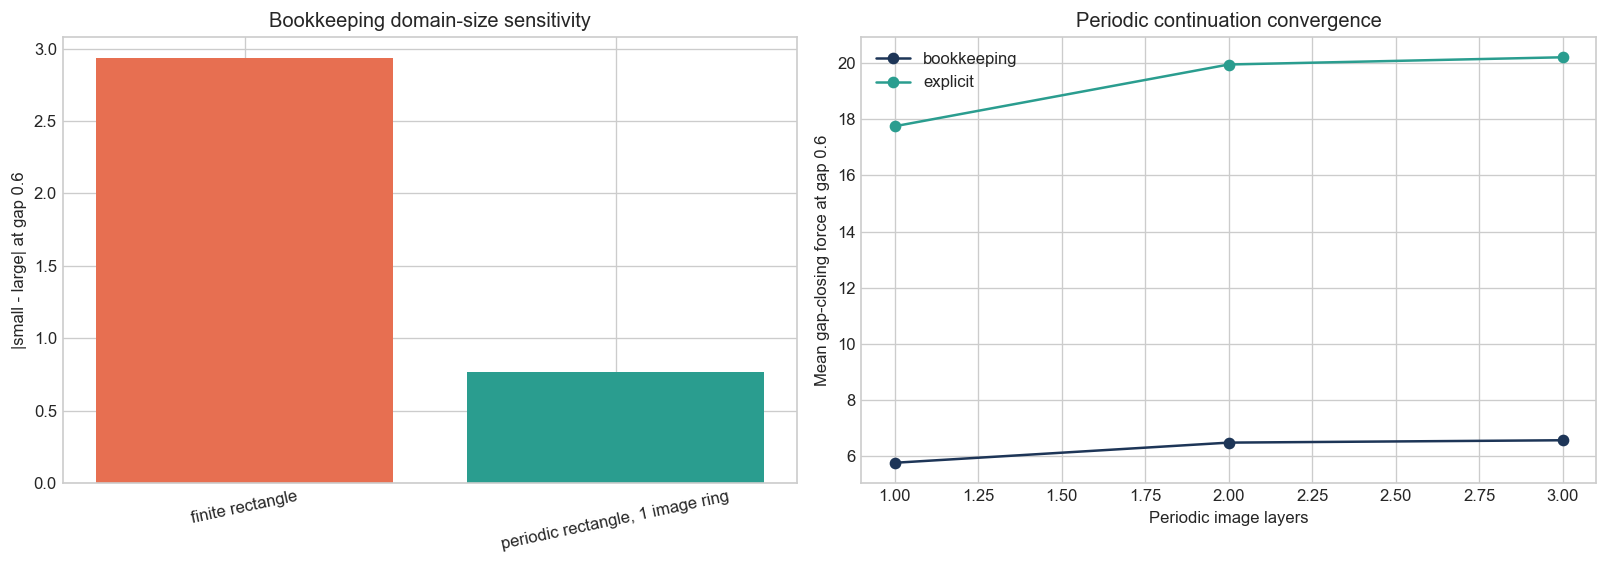

domain-size deltas at gap 0.6
{'support': 'finite rectangle', 'gap': 0.6, 'small_bookkeeping': 1.39, 'large_bookkeeping': 4.323, 'abs_delta_bookkeeping': 2.934, 'small_explicit': 4.361, 'large_explicit': 13.407, 'abs_delta_explicit': 9.046}
{'support': 'periodic rectangle, 1 image ring', 'gap': 0.6, 'small_bookkeeping': 5.756, 'large_bookkeeping': 6.52, 'abs_delta_bookkeeping': 0.764, 'small_explicit': 17.753, 'large_explicit': 20.132, 'abs_delta_explicit': 2.379}

periodic image-layer convergence, small domain, gap 0.6
{'layers': 1, 'bookkeeping': 5.756, 'explicit': 17.753}
{'layers': 2, 'bookkeeping': 6.474, 'explicit': 19.954}
{'layers': 3, 'bookkeeping': 6.559, 'explicit': 20.212}


In [8]:
layer_rows = []
for layers, field in [(1, PERIODIC_SUPPORT_FIELD), (2, PERIODIC_SUPPORT_FIELD_L2), (3, PERIODIC_SUPPORT_FIELD_L3)]:
    summary = support_summary_at_gap(SUPPORT_SMALL_PARAMS, field, gap=SUPPORT_REFERENCE_GAP)
    layer_rows.append({
        'layers': layers,
        'bookkeeping': summary.mean_gap_closing_force,
        'explicit': summary.explicit_mean_gap_closing_force,
    })

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

axes[0].bar(
    [row['support'] for row in support_delta_rows()],
    [row['abs_delta_bookkeeping'] for row in support_delta_rows()],
    color=['#e76f51', '#2a9d8f'],
)
axes[0].set_ylabel('|small - large| at gap 0.6')
axes[0].set_title('Bookkeeping domain-size sensitivity')
axes[0].tick_params(axis='x', rotation=12)

axes[1].plot([row['layers'] for row in layer_rows], [row['bookkeeping'] for row in layer_rows], marker='o', color='#1d3557', label='bookkeeping')
axes[1].plot([row['layers'] for row in layer_rows], [row['explicit'] for row in layer_rows], marker='o', color='#2a9d8f', label='explicit')
axes[1].set_xlabel('Periodic image layers')
axes[1].set_ylabel('Mean gap-closing force at gap 0.6')
axes[1].set_title('Periodic continuation convergence')
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

print('domain-size deltas at gap 0.6')
for row in support_delta_rows():
    print(row)
print()
print('periodic image-layer convergence, small domain, gap 0.6')
for row in layer_rows:
    print({key: round(value, 3) if isinstance(value, float) else value for key, value in row.items()})


## Interpretation of the source-support study

In this reduced comparison, the finite outer rectangle is not a harmless implementation detail. It materially changes the external-field result, especially for the smaller source domain. Under periodic continuation, the same source density gives more stable force curves across the two tested domain sizes, and the attraction seen under the external field persists to larger gaps than it does under the finite small rectangle.

That weakens any claim that the finite rectangular support can be treated as observationally secondary. In the current model, the external-field conclusion is **fragile with respect to the support model**. The body-surface endogenous source model is not directly affected by this change, because it does not sample the external rectangle at all.

The next sensible step is to keep the periodic support option and test whether the external-field attraction remains after varying source density, attenuation length, and periodic image depth together. If it disappears under that robustness pass, the previous external-field attraction should be treated as a boundary-sensitive artifact rather than a stable reduced observation.


## Limitation 5: Only parallel rectangular bodies

Up to this point, body geometry was still restricted to rectangles with zero relative orientation. That makes the minimal model easier to interpret, but it also bakes in a special alignment between the two long sides.

A first reduced extension is to keep the same rectangular bodies and the same event mechanics, but allow symmetric counter-rotation: the upper body is rotated by `+theta`, the lower by `-theta`. This does not solve arbitrary rigid-body dynamics, but it tests whether the earlier conclusions depend strongly on the parallel-side geometry.

In the implementation used here, the gap parameter is preserved as a **centerline inner-side midpoint separation** along the body-to-body axis. That keeps the comparison interpretable even when the side segments are no longer parallel.


In [ ]:
ORIENTATION_BASE_SEED = 520
ORIENTATION_REPEATS = 2
ORIENTATION_GAPS = np.array([0.3, 0.6, 1.0])
ORIENTATION_DEGREES = [0, 15, 30]
ORIENTATION_REFERENCE_GAP = 0.6

ORIENTATION_EXTERNAL_FIELD = SourceField(support='periodic_rectangle', periodic_image_layers=1)
ORIENTATION_BODY_FIELD = SourceField(model='body_surface', emission_offset=0.12)
ORIENTATION_EXTERNAL_DENSITY = 0.5
ORIENTATION_BODY_DENSITY = 2.0

def orientation_angles(angle_deg: float):
    angle_rad = np.deg2rad(angle_deg)
    return (angle_rad, -angle_rad)

def orientation_event_count(source_density: float) -> int:
    return event_count_from_source_density(source_density, BASE_PARAMS)

def orientation_gap_sweep(source_field: SourceField, source_density: float, angle_deg: float):
    return run_gap_ensemble_sweep(
        gaps=ORIENTATION_GAPS,
        params=BASE_PARAMS,
        n_events=orientation_event_count(source_density),
        repeats=ORIENTATION_REPEATS,
        seed=ORIENTATION_BASE_SEED,
        orientation_angles=orientation_angles(angle_deg),
        source_field=source_field,
        shielding_model=GRADED_SHIELDING,
    )

def orientation_summary_at_gap(source_field: SourceField, source_density: float, angle_deg: float, gap: float = ORIENTATION_REFERENCE_GAP):
    return summarize_ensemble(
        run_ensemble(
            gap=gap,
            params=BASE_PARAMS,
            n_events=orientation_event_count(source_density),
            repeats=ORIENTATION_REPEATS,
            seed=ORIENTATION_BASE_SEED,
            orientation_angles=orientation_angles(angle_deg),
            source_field=source_field,
            shielding_model=GRADED_SHIELDING,
        )
    )

def orientation_rows(source_field: SourceField, source_density: float, label: str):
    rows = []
    for angle_deg in ORIENTATION_DEGREES:
        summary = orientation_summary_at_gap(source_field, source_density, angle_deg)
        rows.append({
            'field': label,
            'angle_deg': angle_deg,
            'bookkeeping_gap_0p6': round(summary.mean_gap_closing_force, 3),
            'explicit_gap_0p6': round(summary.explicit_mean_gap_closing_force, 3),
            'system_net': round(summary.mean_system_net_force_y, 3),
            'explicit_system_net': round(summary.explicit_mean_system_net_force_y, 3),
        })
    return rows


## Results: parallel versus counter-rotated rectangles

The next comparison uses the current best external control from the previous study, namely the periodic external support, alongside the endogenous `body_surface` field. The question is whether the interaction sign and magnitude are stable once the long sides are no longer parallel.


In [ ]:
external_orientation_sweeps = {angle_deg: orientation_gap_sweep(ORIENTATION_EXTERNAL_FIELD, ORIENTATION_EXTERNAL_DENSITY, angle_deg) for angle_deg in ORIENTATION_DEGREES}
body_orientation_sweeps = {angle_deg: orientation_gap_sweep(ORIENTATION_BODY_FIELD, ORIENTATION_BODY_DENSITY, angle_deg) for angle_deg in ORIENTATION_DEGREES}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

for angle_deg, color in zip(ORIENTATION_DEGREES, ['#1d3557', '#457b9d', '#8ecae6'], strict=True):
    plot_ensemble_metric(axes[0, 0], external_orientation_sweeps[angle_deg], metric='gap_closing_force', label=f'{angle_deg} deg', color=color)
    plot_ensemble_metric(axes[1, 0], external_orientation_sweeps[angle_deg], metric='explicit_gap_closing_force', label=f'{angle_deg} deg', color=color)

for angle_deg, color in zip(ORIENTATION_DEGREES, ['#bc6c25', '#e76f51', '#f4a261'], strict=True):
    plot_ensemble_metric(axes[0, 1], body_orientation_sweeps[angle_deg], metric='gap_closing_force', label=f'{angle_deg} deg', color=color)
    plot_ensemble_metric(axes[1, 1], body_orientation_sweeps[angle_deg], metric='explicit_gap_closing_force', label=f'{angle_deg} deg', color=color)

axes[0, 0].set_title('External periodic field: bookkeeping')
axes[1, 0].set_title('External periodic field: explicit')
axes[0, 1].set_title('Body-surface field: bookkeeping')
axes[1, 1].set_title('Body-surface field: explicit')

fig.tight_layout()
plt.show()

for row in orientation_rows(ORIENTATION_EXTERNAL_FIELD, ORIENTATION_EXTERNAL_DENSITY, 'external periodic'):
    print(row)
print()
for row in orientation_rows(ORIENTATION_BODY_FIELD, ORIENTATION_BODY_DENSITY, 'body surface'):
    print(row)


## Diagnostics for the orientation study

The main diagnostic here is not only the ensemble mean, but the geometry itself. The plots below show one representative external-field batch and one representative body-surface batch at `0 deg` and `30 deg`, so the change in which boundary segments are exposed is visually explicit.


In [ ]:
external_parallel_batch = simulate_batch(
    gap=ORIENTATION_REFERENCE_GAP,
    params=BASE_PARAMS,
    rng=np.random.default_rng(ORIENTATION_BASE_SEED),
    n_events=orientation_event_count(ORIENTATION_EXTERNAL_DENSITY),
    orientation_angles=orientation_angles(0),
    source_field=ORIENTATION_EXTERNAL_FIELD,
    shielding_model=GRADED_SHIELDING,
)
external_tilted_batch = simulate_batch(
    gap=ORIENTATION_REFERENCE_GAP,
    params=BASE_PARAMS,
    rng=np.random.default_rng(ORIENTATION_BASE_SEED),
    n_events=orientation_event_count(ORIENTATION_EXTERNAL_DENSITY),
    orientation_angles=orientation_angles(30),
    source_field=ORIENTATION_EXTERNAL_FIELD,
    shielding_model=GRADED_SHIELDING,
)
body_parallel_batch = simulate_batch(
    gap=ORIENTATION_REFERENCE_GAP,
    params=BASE_PARAMS,
    rng=np.random.default_rng(ORIENTATION_BASE_SEED),
    n_events=orientation_event_count(ORIENTATION_BODY_DENSITY),
    orientation_angles=orientation_angles(0),
    source_field=ORIENTATION_BODY_FIELD,
    shielding_model=GRADED_SHIELDING,
)
body_tilted_batch = simulate_batch(
    gap=ORIENTATION_REFERENCE_GAP,
    params=BASE_PARAMS,
    rng=np.random.default_rng(ORIENTATION_BASE_SEED),
    n_events=orientation_event_count(ORIENTATION_BODY_DENSITY),
    orientation_angles=orientation_angles(30),
    source_field=ORIENTATION_BODY_FIELD,
    shielding_model=GRADED_SHIELDING,
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_geometry(axes[0, 0], external_parallel_batch, max_events=250)
plot_geometry(axes[0, 1], external_tilted_batch, max_events=250)
plot_geometry(axes[1, 0], body_parallel_batch, max_events=250)
plot_geometry(axes[1, 1], body_tilted_batch, max_events=250)
axes[0, 0].set_title('External periodic field, 0 deg')
axes[0, 1].set_title('External periodic field, 30 deg')
axes[1, 0].set_title('Body-surface field, 0 deg')
axes[1, 1].set_title('Body-surface field, 30 deg')
fig.tight_layout()
plt.show()


## Interpretation of the orientation study

The parallel-body assumption is not neutral. In this reduced extension, counter-rotation weakens the interaction magnitude in both source models. The effect is strongest for the external periodic field, where the short-gap attraction is clearly reduced as the bodies tilt away from parallel alignment. At `30 deg`, the attraction at the smallest tested gap is close to null in the bookkeeping force and remains much weaker in the explicit force.

For the endogenous `body_surface` field, the repulsion also weakens under counter-rotation, but it stays repulsive across the tested gaps and under both force formulations. So the current reduced source-process split survives this geometric relaxation, but the external-field attraction is again more fragile than the endogenous repulsion.

That means the present evidence should be read carefully:

- externally imposed attraction is sensitive not only to source support, but also to relative body orientation
- endogenous body-generated repulsion is more robust across the tested orientation change
- the current notebook still studies a restricted non-parallel family, not arbitrary orientation dynamics or rotation in time

The next sensible step is to keep periodic external support and test a small 2D orientation grid, rather than only symmetric counter-rotation, before adding any rotational dynamics.
